# **EXPERIMENT 4 — TRANSFER LEARNING**

Check the uploaded file

In [ ]:
import os

print("Files uploaded to Colab:")
print(os.listdir("/content"))

Files uploaded to Colab:
['.config', 'Cat and Dog.zip', '.ipynb_checkpoints', 'sample_data']


Find the ZIP filename automatically

In [ ]:
import os

zip_files = [f for f in os.listdir("/content") if f.endswith(".zip")]

print("ZIP files found:")
for f in zip_files:
    print(f)

ZIP files found:
Cat and Dog.zip


Extract the dataset

In [ ]:
import zipfile
import os

zip_file = "/content/" + zip_files[0]
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Check the folder structure

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    if level >= 2:
        continue

dataset/
    cats_set/
    dogs_set/


**TASK A — Dataset Preparation**

Import libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Set dataset path

In [ ]:
dataset_dir = "/content/dataset"

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /content/dataset
Classes: ['cats_set', 'dogs_set']


Load the dataset

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_dataset.class_names

print("Classes:", class_names)

Found 1000 files belonging to 2 classes.
Using 700 files for training.
Found 1000 files belonging to 2 classes.
Using 300 files for validation.
Classes: ['cats_set', 'dogs_set']


Split temporary data into validation and testing

In [ ]:
temp_batches = tf.data.experimental.cardinality(temp_dataset).numpy()

val_batches = temp_batches // 2

validation_dataset = temp_dataset.take(val_batches)
test_dataset = temp_dataset.skip(val_batches)

print("Training batches   :", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches :", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Testing batches    :", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches   : 44
Validation batches : 9
Testing batches    : 10


Optimize datasets

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Dataset preprocessing completed.")

Dataset preprocessing completed.


Display sample images

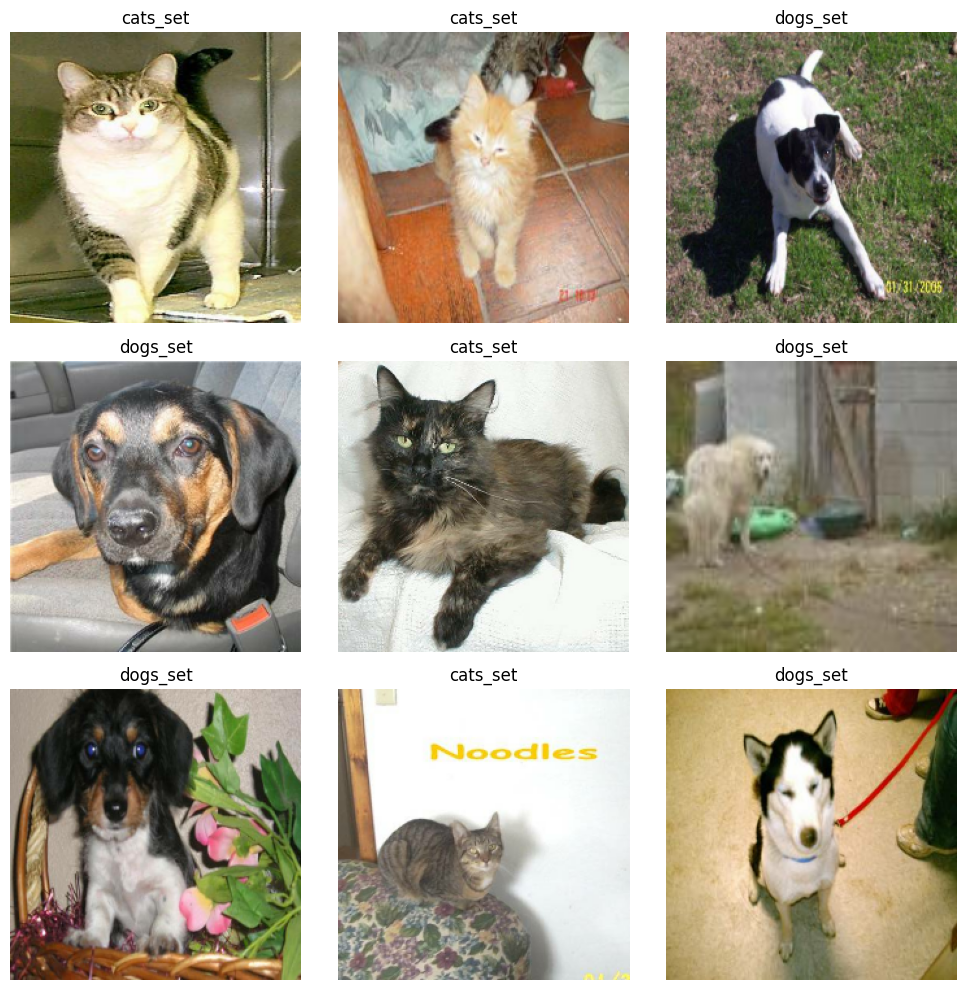

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i][0])
        plt.title(class_names[label])

        plt.axis("off")

plt.tight_layout()
plt.show()

Display dataset information

In [ ]:
print("===== DATASET INFORMATION =====")
print("Image size       :", IMG_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Classes          :", class_names)

print("\n===== DATA SPLIT =====")
print("Training batches   :", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches :", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Testing batches    :", tf.data.experimental.cardinality(test_dataset).numpy())

===== DATASET INFORMATION =====
Image size       : (224, 224)
Batch size       : 16
Classes          : ['cats_set', 'dogs_set']

===== DATA SPLIT =====
Training batches   : 44
Validation batches : 9
Testing batches    : 10


**TASK B — TRANSFER LEARNING USING RESNET50**

Import ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

print("Loading ResNet50...")

Loading ResNet50...


Load the pre-trained ResNet50

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 loaded successfully!


Freeze the feature extraction layers

In [ ]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)
print("Number of layers:", len(base_model.layers))

Base model trainable: False
Number of layers: 175


Build the transfer-learning model

In [ ]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

print("Transfer learning model created!")

Transfer learning model created!


Display the model

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


**TASK C — MODEL TRAINING & EVALUATION**

Train the model

In [ ]:
EPOCHS = 5

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 284ms/step - accuracy: 0.8957 - loss: 0.2328 - val_accuracy: 0.9792 - val_loss: 0.0497
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9657 - loss: 0.0996 - val_accuracy: 0.9792 - val_loss: 0.0513
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9757 - loss: 0.0679 - val_accuracy: 0.9792 - val_loss: 0.0412
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9871 - loss: 0.0456 - val_accuracy: 0.9722 - val_loss: 0.0711
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9871 - loss: 0.0311 - val_accuracy: 0.9792 - val_loss: 0.0654


Get training and validation results

In [ ]:
train_accuracy = history.history["accuracy"][-1]
validation_accuracy = history.history["val_accuracy"][-1]

train_loss = history.history["loss"][-1]
validation_loss = history.history["val_loss"][-1]

print("===== TRAINING RESULTS =====")
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {validation_loss:.4f}")

===== TRAINING RESULTS =====
Training Accuracy   : 0.9871
Validation Accuracy : 0.9792
Training Loss       : 0.0311
Validation Loss     : 0.0654


Evaluate on the test dataset

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("\n===== TEST RESULTS =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.9551 - loss: 0.1255

===== TEST RESULTS =====
Test Loss     : 0.1255
Test Accuracy : 0.9551


Accuracy vs Epoch

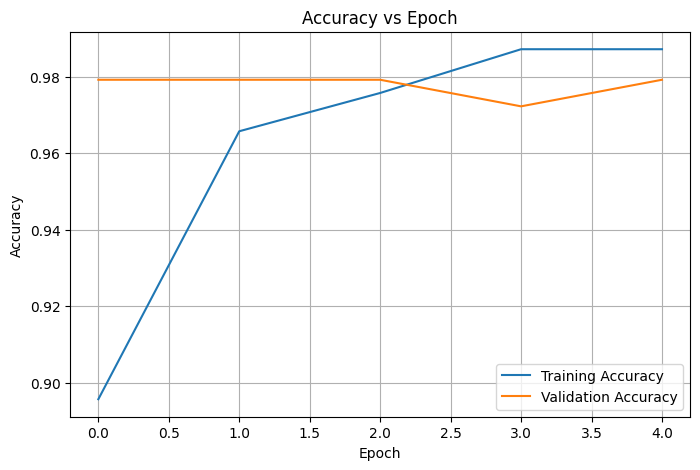

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()

plt.show()

Loss vs Epoch

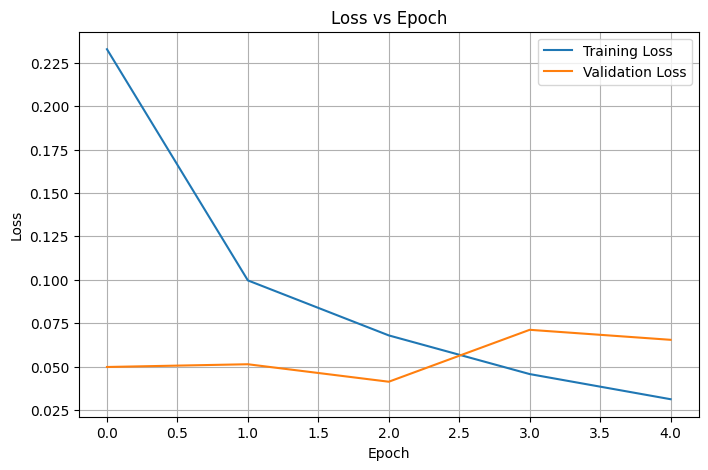

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()

Final Results

In [ ]:
print("=" * 45)
print("       TRANSFER LEARNING RESULTS")
print("=" * 45)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {validation_loss:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print("=" * 45)

       TRANSFER LEARNING RESULTS
Training Accuracy   : 0.9871
Validation Accuracy : 0.9792
Training Loss       : 0.0311
Validation Loss     : 0.0654
Test Accuracy       : 0.9551


**TASK D — Hugging Face**

Install Hugging Face Transformers

In [ ]:
!pip install -q transformers

Load the Hugging Face vision model

In [ ]:
from transformers import pipeline

print("Loading Hugging Face Vision Model...")

hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face model loaded successfully!")

Loading Hugging Face Vision Model...


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face model loaded successfully!


Select a test image

Actual class: dogs_set


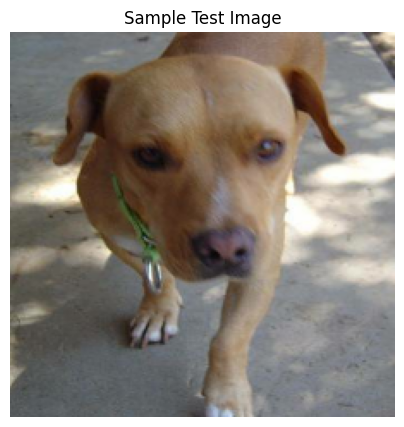

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Get one test image
for images, labels in test_dataset.take(1):
    sample_image = images[0]
    actual_label = int(labels[0][0])

# IMPORTANT: Image is already in 0-255 range
image_array = sample_image.numpy().astype("uint8")

# Convert to PIL
pil_image = Image.fromarray(image_array)

print("Actual class:", class_names[actual_label])

plt.figure(figsize=(5, 5))
plt.imshow(image_array)
plt.title("Sample Test Image")
plt.axis("off")
plt.show()

ResNet50 prediction

In [ ]:
resnet_output = model.predict(
    np.expand_dims(sample_image.numpy(), axis=0),
    verbose=0
)

resnet_probability = float(resnet_output[0][0])

if resnet_probability >= 0.5:
    resnet_prediction = "dogs"
else:
    resnet_prediction = "cats"

print("===== RESNET50 PREDICTION =====")
print("Actual Class      :", class_names[actual_label])
print("Predicted Class   :", resnet_prediction)
print("Dog Probability   :", round(resnet_probability, 4))

===== RESNET50 PREDICTION =====
Actual Class      : dogs_set
Predicted Class   : dogs
Dog Probability   : 1.0


Hugging Face prediction

In [ ]:
hf_results = hf_classifier(pil_image)

print("===== HUGGING FACE PREDICTION =====")

for result in hf_results[:5]:
    print(
        f"{result['label']} : {result['score']:.4f}"
    )

===== HUGGING FACE PREDICTION =====
American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier : 0.3999
Labrador retriever : 0.1136
vizsla, Hungarian pointer : 0.1132
Rhodesian ridgeback : 0.0866
Staffordshire bullterrier, Staffordshire bull terrier : 0.0548


Compare the two models

In [ ]:
print("=" * 60)
print("             MODEL COMPARISON")
print("=" * 60)

print("Actual Class             :", class_names[actual_label])
print("ResNet50 Prediction      :", resnet_prediction)
print("ResNet50 Dog Probability :", round(resnet_probability, 4))

print("\nHugging Face Prediction  :", hf_results[0]["label"])
print("Hugging Face Confidence  :", round(hf_results[0]["score"], 4))

print("=" * 60)

             MODEL COMPARISON
Actual Class             : dogs_set
ResNet50 Prediction      : dogs
ResNet50 Dog Probability : 1.0

Hugging Face Prediction  : American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier
Hugging Face Confidence  : 0.3999


Visual comparison

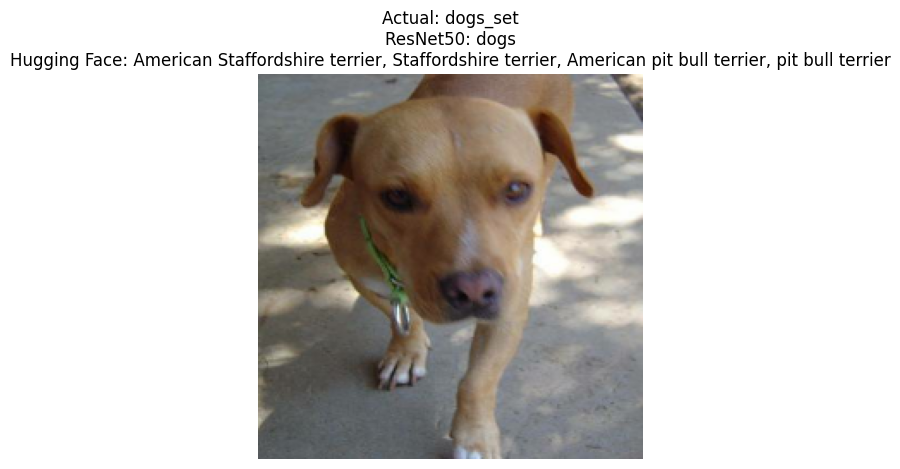

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(image_array)

plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"ResNet50: {resnet_prediction}\n"
    f"Hugging Face: {hf_results[0]['label']}"
)

plt.axis("off")
plt.show()